## **Handling Missing Categorical Data**


1. Imports and Dataset Loading
2. Train-Test Split
3. Data Visualization
4. Strategy 1: Most Frequent Imputation
5. Strategy 2: Missing Category Imputation
6. Key Revision Notes

### **1. Imports and Dataset Loading**

Import the required libraries and load the dataset. Keep only the specific categorical columns and the target variable needed for this workflow.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [3]:
# Load dataset keeping only essential columns
cols = ['GarageQual', 'FireplaceQu', 'SalePrice']
df = pd.read_csv('train.csv', usecols=cols)

### **2. Train-Test Split**

Split the data into training and testing sets *before* applying imputation to prevent data leakage. 

Imputation statistics (like the most frequent category) must be learned strictly from the training set to ensure the model generalizes to unseen data.

In [4]:
# Isolate features and target variable using proper copies
X = df[['GarageQual', 'FireplaceQu']].copy()
y = df['SalePrice'].copy()

# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### **3. Data Visualization (Seaborn)**

Visualize the categorical distribution before applying missing data handling.

C:\Users\ART\AppData\Local\Temp\ipykernel_10420\3332591439.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=X_train, x='GarageQual', palette='viridis')


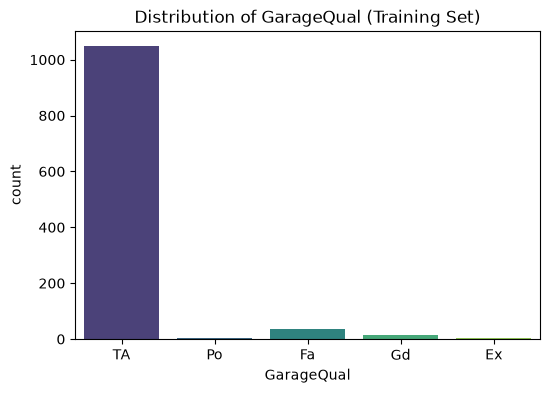

In [5]:
# Plot the distribution of categories using Seaborn
plt.figure(figsize=(6, 4))
sns.countplot(data=X_train, x='GarageQual', palette='viridis')
plt.title('Distribution of GarageQual (Training Set)')
plt.show()

### **4. Strategy 1: Most Frequent Imputation**

Replaces missing values with the most frequent category (the mode) in that specific column.

**When to use:** When missing values are random and one category vastly dominates the distribution.

In [6]:
# Initialize imputer to replace NaN with the most frequent value
imputer_freq = SimpleImputer(strategy='most_frequent')

# Fit strictly on training data, transform both train and test sets
X_train_freq = imputer_freq.fit_transform(X_train)
X_test_freq = imputer_freq.transform(X_test)

# View the learned modes for ['GarageQual', 'FireplaceQu']
print("Learned most frequent values:", imputer_freq.statistics_)

Learned most frequent values: ['TA' 'Gd']


### **5. Strategy 2: Missing Category Imputation**

Replaces all `NaN` values with a new, explicit string category (e.g., 'Missing').

**When to use:** When the fact that data is missing carries predictive signal (e.g., a missing 'FireplaceQu' likely means the house has no fireplace).

In [7]:
# Initialize imputer with a constant fill value
imputer_missing = SimpleImputer(strategy='constant', fill_value='Missing')

# Fit strictly on training data, transform both train and test sets
X_train_missing = imputer_missing.fit_transform(X_train)
X_test_missing = imputer_missing.transform(X_test)

# View the learned constants
print("Learned constant values:", imputer_missing.statistics_)

Learned constant values: ['Missing' 'Missing']


### **Key Revision Notes**

- **Data Leakage Check:** Always perform `train_test_split` BEFORE applying `SimpleImputer`. This ensures you learn statistics exclusively from the training set.
- **Most Frequent Imputation:** Setting `strategy='most_frequent'` replaces `NaN` with the mode. It is ideal for MCAR (Missing Completely at Random) data featuring a dominant category.
- **Missing Category Imputation:** Setting `strategy='constant'` with `fill_value='Missing'` creates a distinct category. It is ideal when missingness is structural (e.g., NA = No Garage).
- **Scikit-Learn over Pandas:** Use `SimpleImputer` over `pandas.fillna()` in machine learning pipelines because `SimpleImputer` seamlessly stores learned statistics to apply symmetrically to testing data and production inputs.